<a href="https://colab.research.google.com/github/blongho/pspit/blob/master/pspit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Replacing LSTM with ESM-2 for Small Prokaryotic Protein Identification

This notebook implements an improved version of the PSPI model by replacing the hand-crafted features + LSTM with a frozen **ESM-2 protein language model** followed by a simple classifier. The approach:

1. Load the same dataset as PSPI (`datasets/training/positives`, `datasets/training/negatives`, etc.)
2. Extract **mean-pooled embeddings** from ESM-2 (no fine-tuning by default)
3. Train a logistic regression (or a small MLP) on these embeddings
4. Evaluate using the **same 12-fold subsampling protocol** as the original PSPI
5. Fine-tune ESM-2 for potentially better performance

The notebook is self-contained and can be run on Google Colab (free GPU) or a local machine with PyTorch and a GPU.

## Requirements
- Python 3.8+
- PyTorch
- Transformers (Hugging Face)
- scikit-learn
- Biopython
- tqdm
- numpy, pandas, matplotlib


In [2]:
# @title Environment setup
import os
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab. Mounting Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive')
    project_dir = '/content/drive/MyDrive/pspi'
else:
    print("Running locally. Make sure you have the required packages installed.")
    project_dir = '.'  # or your local path

os.chdir(project_dir)
print(f"Working directory: {os.getcwd()}")

Running in Google Colab. Mounting Google Drive...
Mounted at /content/drive
Working directory: /content/drive/MyDrive/pspi


In [3]:
# @title Install dependences
!pip install -q torch transformers scikit-learn biopython tqdm matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.8 MB/s eta 0:00:00


In [4]:
# @title Import dependences
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from Bio import SeqIO

import torch
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, confusion_matrix, roc_curve, precision_recall_curve

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
  print(f"Using cuda {torch.cuda.get_device_properties()}")
  torch.cuda.manual_seed_all(SEED)

Using cuda _CudaDeviceProperties(name='Tesla T4', major=7, minor=5, total_memory=14912MB, multi_processor_count=40, uuid=1acf6975-2e89-ca46-d645-400c0bff6d68, pci_bus_id=0, pci_device_id=4, pci_domain_id=0, L2_cache_size=4MB)


## 1. Load Dataset

The dataset is expected in the following structure (same as PSPI):

```
datasets/
├── training/
│   ├── positives/      # FASTA files
│   └── negatives/      # FASTA files
└── testing/
    ├── positives/
    └── negatives/
```

We will parse all `.fasta`, `.fa`, or `.txt` files and extract the sequences.

In [5]:
import os

pos_dir = "datasets/training/positives/"
print(f"Positives directory exists: {os.path.exists(pos_dir)}")
if os.path.exists(pos_dir):
    files = os.listdir(pos_dir)
    print(f"Files in positives directory: {files[:10]}")  # show first 10
    # Check if any files have FASTA extensions
    fasta_files = [f for f in files if f.endswith((".fasta", ".fa", ".fas", ".txt"))]
    print(f"FASTA files found: {len(fasta_files)}")

Positives directory exists: True
Files in positives directory: ['prokaryotes6318.fas']
FASTA files found: 1


In [6]:
def load_sequences_from_directory(base_dir, label):
    """
    Recursively read all FASTA files in base_dir and return list of (sequence, label).
    """
    sequences = []
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith((".fasta", ".fa", ".txt", ".fas")):
                filepath = os.path.join(root, file)
                with open(filepath, 'r') as f:
                    for record in SeqIO.parse(f, 'fasta'):
                        sequences.append((str(record.seq), label))
    return sequences

# Adjust these paths if necessary
train_pos = load_sequences_from_directory('datasets/training/positives/', label=1)
train_neg = load_sequences_from_directory('datasets/training/negatives/', label=0)
train_data = train_pos + train_neg

test_pos = load_sequences_from_directory('datasets/testing/positives/', label=1)
test_neg = load_sequences_from_directory('datasets/testing/negatives/', label=0)
test_data = test_pos + test_neg

print(f"Training: {len(train_data)} sequences (positive: {len(train_pos)}, negative: {len(train_neg)})")
print(f"Testing: {len(test_data)} sequences (positive: {len(test_pos)}, negative: {len(test_neg)})")

# Separate sequences and labels for later use
train_seqs = [seq for seq, _ in train_data]
train_labels = [lab for _, lab in train_data]
test_seqs = [seq for seq, _ in test_data]
test_labels = [lab for _, lab in test_data]

Training: 29925 sequences (positive: 6318, negative: 23607)
Testing: 54609 sequences (positive: 31125, negative: 23484)


## 2. Load ESM‑2 Model (Frozen)

We will use the smallest ESM‑2 variant (`esm2_t6_8M_UR50D`, 8M parameters) for speed and memory efficiency. You can switch to larger models if you have more GPU memory.

**Model options**:
- `facebook/esm2_t6_8M_UR50D` – 8M params, 320-dim embeddings
- `facebook/esm2_t12_35M_UR50D` – 35M params, 480-dim
- `facebook/esm2_t30_150M_UR50D` – 150M params, 640-dim
- `facebook/esm2_t33_650M_UR50D` – 650M params, 1280-dim

In [7]:
model_name = "facebook/esm2_t6_8M_UR50D"  # smallest, fastest
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()  # freeze the model
print(f"Using device: {device}")
print(f"Model hidden size: {model.config.hidden_size}")

config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda
Model hidden size: 320


## 3. Extract Embeddings

We will compute a **mean‑pooled** embedding for each sequence (average over amino acid positions). This yields one fixed‑length vector per protein.

**Note**: For large datasets, this step may take a few minutes. We’ll process sequences in batches for efficiency.

In [8]:
def get_embeddings_batch(sequences, batch_size=32):
    """
    Extract mean-pooled embeddings for a list of sequences.
    Returns a numpy array of shape (len(sequences), hidden_size).
    """
    embeddings = []
    for i in tqdm(range(0, len(sequences), batch_size), desc="Extracting embeddings"):
        batch_seqs = sequences[i:i+batch_size]
        # Tokenize
        inputs = tokenizer(batch_seqs, return_tensors='pt', truncation=True, max_length=1022, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        # outputs.last_hidden_state: (batch, seq_len, hidden_size)
        # Mean over seq_len dimension (ignoring padding? We'll use simple mean, it's fine for short proteins)
        batch_embeds = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        embeddings.append(batch_embeds)
    return np.concatenate(embeddings, axis=0)

# Extract embeddings for training and test sets
print("Extracting training embeddings...")
X_train = get_embeddings_batch(train_seqs)
y_train = np.array(train_labels)

print("Extracting test embeddings...")
X_test = get_embeddings_batch(test_seqs)
y_test = np.array(test_labels)

print(f"Train embeddings shape: {X_train.shape}")
print(f"Test embeddings shape: {X_test.shape}")

Extracting training embeddings...


Extracting embeddings: 100%|██████████| 936/936 [00:37<00:00, 25.09it/s]


Extracting test embeddings...


Extracting embeddings: 100%|██████████| 1707/1707 [01:06<00:00, 25.50it/s]

Train embeddings shape: (29925, 320)
Test embeddings shape: (54609, 320)


## 4. Train a Classifier on Frozen Embeddings

We use logistic regression with balanced class weights. This is fast and often works well for frozen embeddings.

In [9]:
clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)
clf.fit(X_train, y_train)

# Predict probabilities and classes
y_pred_proba = clf.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

# Compute metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
sensitivity = tp / (tp + fn) if (tp+fn) > 0 else 0
specificity = tn / (tn + fp) if (tn+fp) > 0 else 0
precision = tp / (tp + fp) if (tp+fp) > 0 else 0

print("===== Full Test Set Performance =====")
print(f"Precision:  {precision:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 score:    {f1:.4f}")
print(f"AUROC:       {roc_auc:.4f}")
print(f"AUPRC:       {auprc:.4f}")

===== Full Test Set Performance =====
Precision:  0.9859
Sensitivity: 0.9648
Specificity: 0.9818
F1 score:    0.9752
AUROC:       0.9947
AUPRC:       0.9966


## 5. Save the trained classifier

We will save the trained Logistic Regression classifier using `joblib` so it can be reloaded later for inference without needing to retrain.

In [10]:
import joblib

# Define the path to save the model
model_save_path = 'logistic_regression_esm2_classifier.joblib'

# Save the model
joblib.dump(clf, model_save_path)

print(f"Trained model saved to {model_save_path}")

Trained model saved to logistic_regression_esm2_classifier.joblib


In [11]:
# @title Experiment with other classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Linear SVM': LinearSVC(class_weight='balanced', dual='auto', max_iter=2000),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    if name == 'Linear SVM':
        y_score = clf.decision_function(X_test)
    else:
        y_score = clf.predict_proba(X_test)[:, 1]
    roc = roc_auc_score(y_test, y_score)
    pr = average_precision_score(y_test, y_score)
    print(f"{name}: AUROC={roc:.4f}, AUPRC={pr:.4f}")

Logistic Regression: AUROC=0.9947, AUPRC=0.9966
Linear SVM: AUROC=0.9954, AUPRC=0.9971
Random Forest: AUROC=0.9911, AUPRC=0.9947


## 5. Replicate PSPI’s 12‑Fold Subsampling Evaluation

The original PSPI paper randomly sampled 1000 positive and 1000 negative sequences from the test set (with replacement if necessary) and repeated this 12 times. We will do the same to allow a direct comparison.

**Important**: PSPI trained the LSTM once on the full training set and then evaluated on each subsample. We will follow the same protocol: use the logistic regression trained on the **full training embeddings** (above) and evaluate on each subsample of the test set.

In [12]:
n_trials = 12
trial_metrics = {'auroc': [], 'auprc': [], 'f1': [], 'precision': [], 'sensitivity': [], 'specificity': []}

# Get indices of positives and negatives in the test set
pos_indices = [i for i, label in enumerate(test_labels) if label == 1]
neg_indices = [i for i, label in enumerate(test_labels) if label == 0]

for trial in range(n_trials):
    # Sample (with replacement if needed) 1000 positives and 1000 negatives
    sample_pos = random.choices(pos_indices, k=1000) if len(pos_indices) >= 1000 else random.sample(pos_indices, len(pos_indices))
    sample_neg = random.choices(neg_indices, k=1000) if len(neg_indices) >= 1000 else random.sample(neg_indices, len(neg_indices))
    sample_idx = sample_pos + sample_neg

    X_sub = X_test[sample_idx]
    y_sub = y_test[sample_idx]

    y_pred_proba_sub = clf.predict_proba(X_sub)[:, 1]
    y_pred_sub = (y_pred_proba_sub >= 0.5).astype(int)

    # Metrics
    roc = roc_auc_score(y_sub, y_pred_proba_sub)
    pr = average_precision_score(y_sub, y_pred_proba_sub)
    f1 = f1_score(y_sub, y_pred_sub)
    tn, fp, fn, tp = confusion_matrix(y_sub, y_pred_sub).ravel()
    prec = tp / (tp+fp) if (tp+fp) > 0 else 0
    sens = tp / (tp+fn) if (tp+fn) > 0 else 0
    spec = tn / (tn+fp) if (tn+fp) > 0 else 0

    trial_metrics['auroc'].append(roc)
    trial_metrics['auprc'].append(pr)
    trial_metrics['f1'].append(f1)
    trial_metrics['precision'].append(prec)
    trial_metrics['sensitivity'].append(sens)
    trial_metrics['specificity'].append(spec)

print("===== 12‑Fold Subsampling Results =====")
for metric in trial_metrics:
    values = trial_metrics[metric]
    print(f"{metric.capitalize()}: {np.mean(values):.4f} ± {np.std(values):.4f}")

# Also show the average of the 12 trials (as PSPI does)
print("\nAverage over 12 trials:")
print(f"AUROC:   {np.mean(trial_metrics['auroc']):.4f}")
print(f"AUPRC:   {np.mean(trial_metrics['auprc']):.4f}")
print(f"F1:      {np.mean(trial_metrics['f1']):.4f}")
print(f"Precision: {np.mean(trial_metrics['precision']):.4f}")
print(f"Sensitivity: {np.mean(trial_metrics['sensitivity']):.4f}")
print(f"Specificity: {np.mean(trial_metrics['specificity']):.4f}")

===== 12‑Fold Subsampling Results =====
Auroc: 0.9912 ± 0.0018
Auprc: 0.9934 ± 0.0012
F1: 0.9657 ± 0.0035
Precision: 0.9945 ± 0.0016
Sensitivity: 0.9386 ± 0.0065
Specificity: 0.9948 ± 0.0015

Average over 12 trials:
AUROC:   0.9912
AUPRC:   0.9934
F1:      0.9657
Precision: 0.9945
Sensitivity: 0.9386
Specificity: 0.9948


## 6. Visualisation (ROC and PR Curves)

We can plot the ROC and precision‑recall curves for one representative subsample (or the full test set).

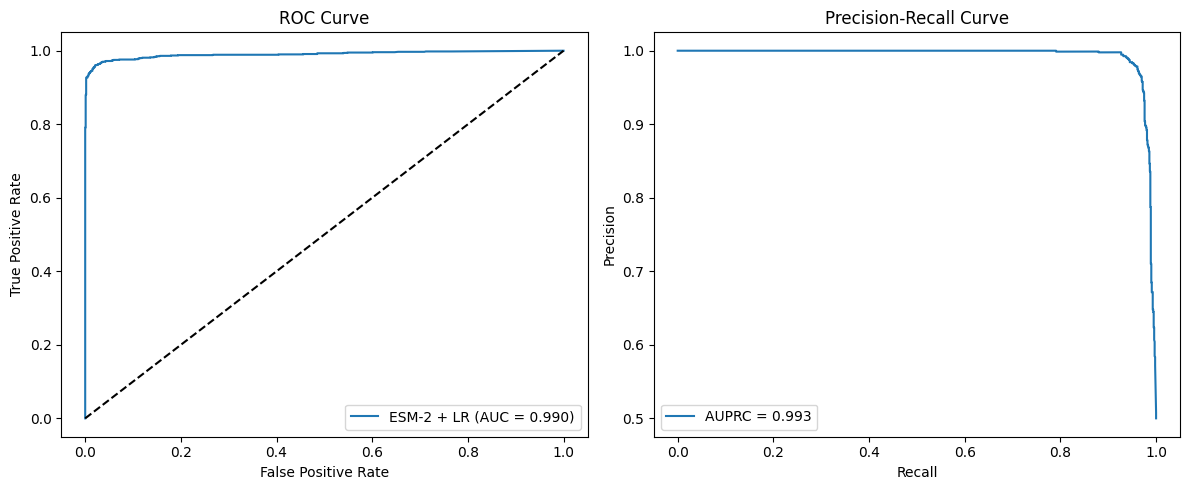

In [13]:
# Use the first trial subsample for curves
sample_pos = random.choices(pos_indices, k=1000) if len(pos_indices) >= 1000 else random.sample(pos_indices, len(pos_indices))
sample_neg = random.choices(neg_indices, k=1000) if len(neg_indices) >= 1000 else random.sample(neg_indices, len(neg_indices))
sample_idx = sample_pos + sample_neg
X_plot = X_test[sample_idx]
y_plot = y_test[sample_idx]
y_proba_plot = clf.predict_proba(X_plot)[:, 1]

fpr, tpr, _ = roc_curve(y_plot, y_proba_plot)
roc_auc = roc_auc_score(y_plot, y_proba_plot)

precision_curve, recall_curve, _ = precision_recall_curve(y_plot, y_proba_plot)
auprc_curve = average_precision_score(y_plot, y_proba_plot)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(fpr, tpr, label=f'ESM‑2 + LR (AUC = {roc_auc:.3f})')
ax1.plot([0,1], [0,1], 'k--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()

ax2.plot(recall_curve, precision_curve, label=f'AUPRC = {auprc_curve:.3f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision‑Recall Curve')
ax2.legend()
plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Fine‑Tuning ESM‑2

If you have a GPU and want to attempt further improvement, you can fine‑tune the entire ESM‑2 model on the training set. **Note**: This is computationally expensive and may overfit on small data. Use with caution.

We will use the `AutoModelForSequenceClassification` class, which adds a classification head on top of the ESM‑2 encoder.

In [ ]:
#Fine‑tuning ESM‑2 (only if you have a GPU)
class ProteinDataset(Dataset):
    def __init__(self, sequences, labels, tokenizer, max_len=1022):
        self.sequences = sequences
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, idx):
        seq = self.sequences[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            seq,
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Prepare datasets
train_dataset = ProteinDataset(train_seqs, train_labels, tokenizer)
test_dataset = ProteinDataset(test_seqs, test_labels, tokenizer)

# Load model for sequence classification
finetune_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
finetune_model.to(device)

# Training arguments
training_args = TrainingArguments(
    output_dir='./esm2_finetune_results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    fp16=True,
)

trainer = Trainer(
    model=finetune_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    # tokenizer is not needed here
)

trainer.train()

# Evaluate fine‑tuned model
predictions = trainer.predict(test_dataset)
y_pred_proba_ft = torch.softmax(torch.tensor(predictions.predictions), dim=1)[:, 1].numpy()
y_pred_ft = (y_pred_proba_ft >= 0.5).astype(int)

roc_auc_ft = roc_auc_score(test_labels, y_pred_proba_ft)
auprc_ft = average_precision_score(test_labels, y_pred_proba_ft)
f1_ft = f1_score(test_labels, y_pred_ft)
print(f"Fine‑tuned model: AUROC={roc_auc_ft:.4f}, AUPRC={auprc_ft:.4f}, F1={f1_ft:.4f}")

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmForSequenceClassification LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss
1,0.076956,0.082789


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
model_save_path_finetuned = './esm2_finetuned_classifier'
trainer.save_model(model_save_path_finetuned)
print(f'Fine-tuned model saved to {model_save_path_finetuned}')